<a href="https://colab.research.google.com/github/Ololade117/stat4datascience/blob/main/SQ4DS_Lecture_4.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Statistics and Quantitative Methods for Data Science
[© Silvadew Institute](https://institute.silvadew.com/course-details/?c=43177d50)

# Lecture 7-  Exploratory Data Analysis & Correlation
### Statistics & Quantitative Methods for Data Science

We now shift from testing single claims (Week 3) to exploring **relationships between variables** — the foundation for regression, feature selection, and machine learning later in the course.

**This notebook:**
1. What is EDA, and a repeatable workflow
2. Correlation between two numeric variables (Pearson & Spearman)
3. Visualizing relationships (scatter, pairplot, heatmap)
4. Numeric-vs-categorical associations (point-biserial, ANOVA)
5. Categorical-vs-categorical association (Cramér's V)
6. Correlation is not causation
7. Exercises


## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (7, 4)

TITANIC_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
titanic = pd.read_csv(TITANIC_URL)
titanic.head(3)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True


---
# 1. What is EDA?

**Exploratory Data Analysis** is the systematic process of getting to know a dataset *before* modelling it: checking shape, types, missing values, distributions, and relationships. A simple repeatable workflow:

1. Shape & data types (`.info()`)
2. Missing values
3. Univariate summaries (Weeks 1-2: descriptive stats & distributions)
4. **Bivariate relationships** (this class's focus)
5. Multivariate patterns (heatmaps, pairplots)

In [ ]:
titanic.info()
print("\nMissing values per column:")
print(titanic.isnull().sum()[titanic.isnull().sum() > 0])

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB

Missing values per column:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64


---
# 2. Correlation between two numeric variables

**Pearson correlation** $r$ measures the strength of a **linear** relationship, from -1 (perfect negative) to +1 (perfect positive), 0 = no linear relationship.

$$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i-\bar{x})^2}\sqrt{\sum(y_i-\bar{y})^2}}$$

**Spearman correlation** measures **monotonic** relationships (does y consistently increase/decrease as x does, even if not linearly) — it correlates the *ranks* instead of the raw values, making it robust to outliers and nonlinearity.

In [ ]:
df = titanic.dropna(subset=['age', 'fare'])

pearson_r, pearson_p = stats.pearsonr(df['age'], df['fare'])
spearman_r, spearman_p = stats.spearmanr(df['age'], df['fare'])

print(f"Pearson r  = {pearson_r:.3f}  (p={pearson_p:.4f})")
print(f"Spearman r = {spearman_r:.3f}  (p={spearman_p:.4f})")
print("-> Age and fare have only a weak relationship in either sense.")

Pearson r  = 0.096  (p=0.0102)
Spearman r = 0.135  (p=0.0003)
-> Age and fare have only a weak relationship in either sense.


In [ ]:
# A clearer example: pclass (ordinal-ish) vs fare -- strongly related
pearson_r, _ = stats.pearsonr(titanic['pclass'], titanic['fare'])
spearman_r, _ = stats.spearmanr(titanic['pclass'], titanic['fare'])
print(f"pclass vs fare -- Pearson r = {pearson_r:.3f}, Spearman r = {spearman_r:.3f}")
print("Both strongly negative: lower class NUMBER (i.e. 1st class) pays a higher fare.")

pclass vs fare -- Pearson r = -0.549, Spearman r = -0.688
Both strongly negative: lower class NUMBER (i.e. 1st class) pays a higher fare.


Pearson r  = 0.9342
Spearman r = 1.0000   <- catches the perfect monotonic relationship


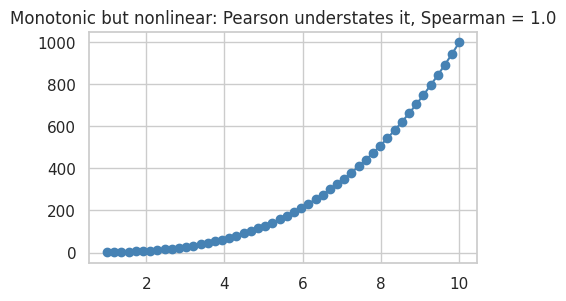

In [ ]:
# Why Spearman can differ from Pearson: a monotonic but curved (nonlinear) relationship
x = np.linspace(1, 10, 50)
y = x**3   # perfectly monotonic, but NOT linear
print(f"Pearson r  = {stats.pearsonr(x, y)[0]:.4f}")
print(f"Spearman r = {stats.spearmanr(x, y)[0]:.4f}   <- catches the perfect monotonic relationship")

fig, ax = plt.subplots(figsize=(5,3))
ax.plot(x, y, 'o-', color='steelblue')
ax.set_title('Monotonic but nonlinear: Pearson understates it, Spearman = 1.0')
plt.show()

---
# 3. Visualizing relationships

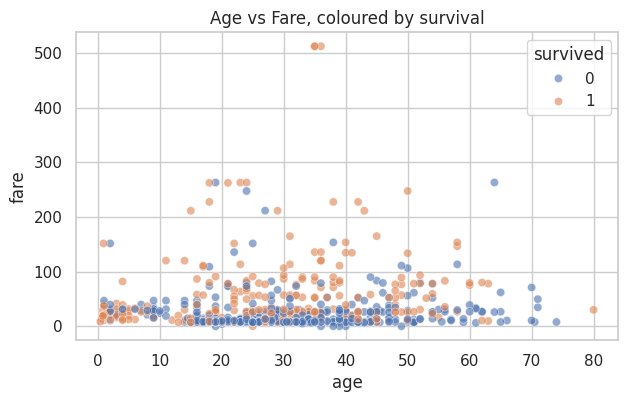

In [ ]:
sns.scatterplot(data=titanic, x='age', y='fare', hue='survived', alpha=0.6)
plt.title('Age vs Fare, coloured by survival')
plt.show()

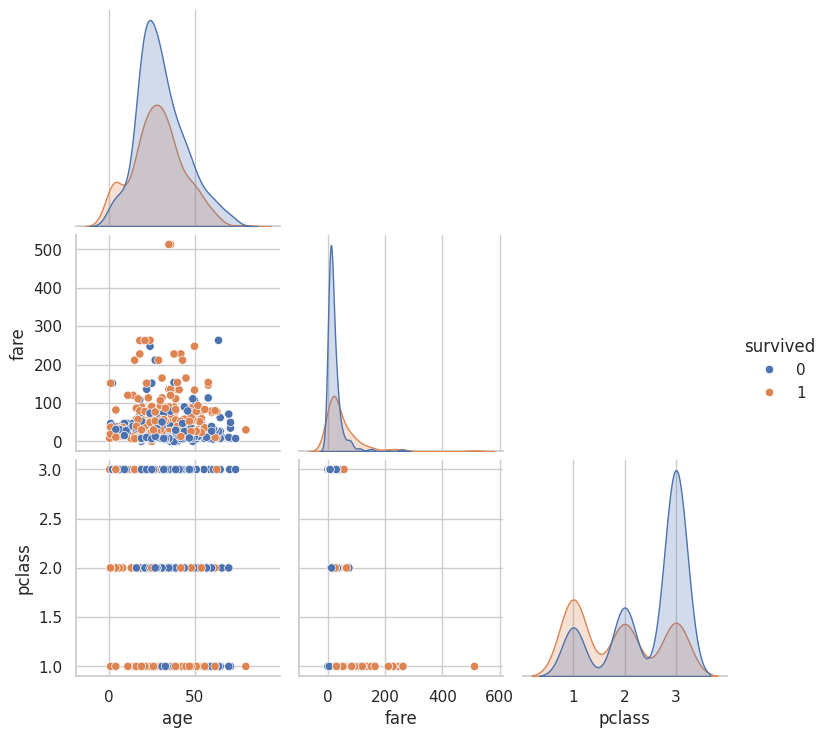

In [ ]:
sns.pairplot(titanic[['age', 'fare', 'pclass', 'survived']].dropna(), hue='survived', corner=True)
plt.show()

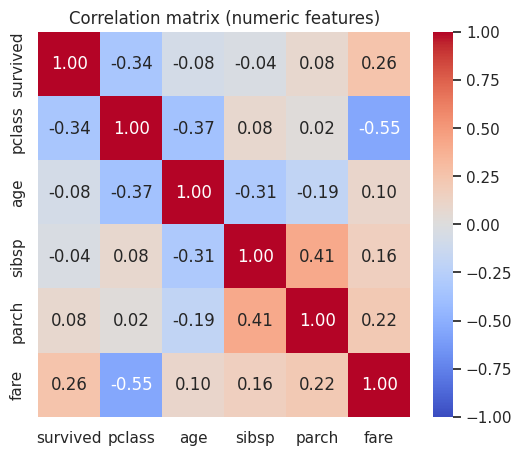

In [ ]:
numeric_cols = titanic.select_dtypes(include=np.number)
corr = numeric_cols.corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation matrix (numeric features)')
plt.show()

---
# 4. Numeric-vs-categorical associations

Pearson/Spearman need two *numeric* variables. To relate a numeric variable to a **binary** categorical one (like `survived`), the **point-biserial correlation** is just Pearson's r applied to the 0/1 variable — scipy provides it directly. For a categorical variable with **3+ levels** (like `pclass`), we already met the right tool in Week 3: **one-way ANOVA**.

In [ ]:
df2 = titanic.dropna(subset=['fare', 'survived'])
r_pb, p_pb = stats.pointbiserialr(df2['survived'], df2['fare'])
print(f"Point-biserial correlation (survived, fare): r = {r_pb:.3f}, p = {p_pb:.2e}")
print("-> Higher fare is associated with a higher chance of survival.")

Point-biserial correlation (survived, fare): r = 0.257, p = 6.12e-15
-> Higher fare is associated with a higher chance of survival.


In [ ]:
# ANOVA: does age differ meaningfully across the 3 pclass groups? (recap from Week 3, applied here as an association measure)
age_by_class = [titanic.loc[titanic.pclass==c, 'age'].dropna() for c in [1,2,3]]
f_stat, p_val = stats.f_oneway(*age_by_class)
print(f"F = {f_stat:.2f}, p = {p_val:.2e}")
print("pclass and age are significantly associated." if p_val < 0.05 else "No significant association.")

F = 57.44, p = 7.49e-24
pclass and age are significantly associated.


---
# 5. Categorical-vs-categorical: Cramér's V

Chi-square (Week 3) tells you *whether* two categorical variables are associated. **Cramér's V** rescales the chi-square statistic to a 0-1 range, giving you the **strength** of association (like a correlation coefficient, but for categorical data):

$$V = \sqrt{\frac{\chi^2 / n}{\min(r-1, c-1)}}$$

In [ ]:
def cramers_v(cat1, cat2):
    contingency = pd.crosstab(cat1, cat2)
    chi2, _, _, _ = stats.chi2_contingency(contingency)
    n = contingency.sum().sum()
    r, c = contingency.shape
    return np.sqrt((chi2 / n) / (min(r-1, c-1)))

print(f"Cramer's V (sex, survived):        {cramers_v(titanic['sex'], titanic['survived']):.3f}  <- strong")
print(f"Cramer's V (pclass, survived):     {cramers_v(titanic['pclass'], titanic['survived']):.3f}  <- moderate")
print(f"Cramer's V (embark_town, survived):{cramers_v(titanic['embark_town'].dropna(), titanic.loc[titanic['embark_town'].notna(),'survived']):.3f}  <- weak")

Cramer's V (sex, survived):        0.541  <- strong
Cramer's V (pclass, survived):     0.340  <- moderate
Cramer's V (embark_town, survived):0.173  <- weak


---
# 6. Correlation is not causation

A strong correlation only tells you two variables *move together* — not that one *causes* the other. Classic confounds:

- **Reverse causation**: does A cause B, or B cause A?
- **Confounding variable**: a third variable causes both.
- **Coincidence**: especially with small samples or many comparisons tested at once.

In Titanic: `fare` correlates with `survived` — but fare doesn't *cause* survival directly. Both are driven by a **confounder**: passenger class, which determined both ticket price *and* proximity to lifeboats/deck level.

In [ ]:
# Show the confound: within each pclass, the fare-survival correlation weakens substantially
for c in [1, 2, 3]:
    sub = titanic[titanic.pclass == c].dropna(subset=['fare','survived'])
    r, _ = stats.pointbiserialr(sub['survived'], sub['fare'])
    print(f"pclass={c}:  correlation(fare, survived) = {r:.3f}  (n={len(sub)})")
print("\n-> The overall correlation was partly a stand-in for class, not a direct fare effect.")

pclass=1:  correlation(fare, survived) = 0.191  (n=216)
pclass=2:  correlation(fare, survived) = 0.099  (n=184)
pclass=3:  correlation(fare, survived) = 0.001  (n=491)

-> The overall correlation was partly a stand-in for class, not a direct fare effect.


---
# 7. Exercises

1. Compute the Pearson and Spearman correlation between `sibsp` (siblings/spouses aboard) and `fare`. Are they close to each other? What would a big gap between them suggest?
2. Make a `sns.heatmap` of the correlation matrix restricted to `['survived', 'pclass', 'age', 'fare', 'sibsp', 'parch']`. Which pair has the strongest correlation, excluding the diagonal?
3. Compute the point-biserial correlation between `survived` and `age`. Is age more or less associated with survival than fare was?
4. Compute Cramér's V between `pclass` and `embark_town`. Does where someone embarked relate to what class they travelled in?
5. **Challenge**: Repeat the "correlation is not causation" analysis from Section 6, but split by `sex` instead of `pclass`. Does the fare-survival correlation still hold up within each sex group, or does it weaken there too?
